# 3D Segmentation to Minkowski Tensor Analysis

This notebook demonstrates an end-to-end pipeline for analysing 3D cell morphology using Minkowski tensors. Starting from a raw confocal fluorescence stack, we segment individual nuclei, compute their full set of Minkowski tensors with **pykarambola**, colour-code reconstructed 3D meshes by shape anisotropy, and finally cluster the nuclei in a low-dimensional PCA space derived from tensor features.

**Dataset:** `skimage.data.cells3d()` — a 60-slice confocal stack of HeLa cells with two channels (cell membrane and nuclei stained with SYTO 16), acquired at voxel spacing Z = 0.29 µm, Y = X = 0.2645 µm.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from scipy import ndimage
from skimage import data, filters, measure, util, exposure
from skimage.morphology import h_maxima
from skimage.segmentation import watershed, clear_border
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
import pykarambola as pk

/Users/yk/anaconda3/envs/pykarambola/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Shape: (60, 256, 256)  dtype: uint16
Voxel spacing: Z=0.29 µm, Y=0.2645 µm, X=0.2645 µm


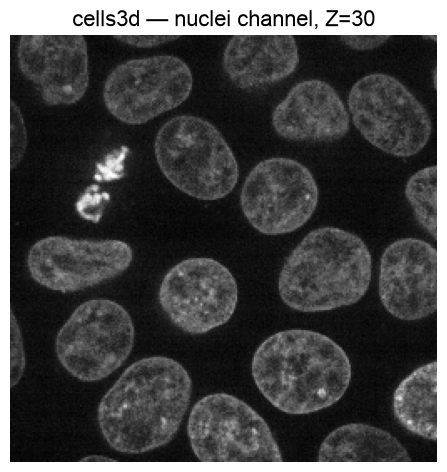

In [2]:
plt.rcParams['font.family'] = 'Arial'
plt.rcParams.update({
    'font.size':       16,
    'axes.titlesize':  16,
    'axes.labelsize':  15,
    'xtick.labelsize': 13,
    'ytick.labelsize': 13,
})

cells = data.cells3d()          # (60, 2, 256, 256) uint16, axes: Z C Y X
membrane = cells[:, 0, :, :]   # channel 0 = cell membrane
nuclei   = cells[:, 1, :, :]   # channel 1 = nuclei (SYTO 16)

# physical voxel spacing (Z, Y, X) in µm — from skimage docs
SPACING = (0.29, 0.2645, 0.2645)

print(f"Shape: {nuclei.shape}  dtype: {nuclei.dtype}")
print(f"Voxel spacing: Z={SPACING[0]} µm, Y={SPACING[1]} µm, X={SPACING[2]} µm")

# show mid-Z slice
fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(nuclei[30], cmap='Grays_r')
ax.axis('off')
ax.set_title('cells3d — nuclei channel, Z=30')
plt.tight_layout()
plt.savefig('../assets/demo_raw.png', dpi=150, bbox_inches='tight')
plt.show()

## Preprocessing & Segmentation

Accurate segmentation of individual nuclei is the foundation of any morphometric analysis — errors here (merged nuclei, fragmented objects, topological holes) propagate directly into the Minkowski tensor values and corrupt downstream shape comparisons.

The HeLa nuclei in this dataset present two classic challenges: **closely apposed neighbours** (nuclei touching along a shared membrane ridge) and **internal intensity heterogeneity** (dark chromatin domains that mimic background). The pipeline below addresses both:

1. **Anisotropic Gaussian smoothing** (σ = 0.3 µm, applied independently per axis to account for the coarser Z-sampling) — suppresses pixel-level shot noise while keeping the dim intensity valleys between adjacent nuclei intact. Over-smoothing here would cause neighbouring nuclei to merge into a single foreground blob.

2. **Global Otsu thresholding** — separates nucleus voxels from background. A single global threshold is sufficient after Gaussian smoothing; adaptive per-plane thresholds are not needed and introduce Z-discontinuities that fragment nuclei.

3. **3D `binary_fill_holes`** — nuclei contain heterochromatin domains that are darker than the cytoplasm and can fall below the Otsu threshold, punching holes through the binary mask. These holes generate spurious local maxima in the distance transform that seed phantom daughter-nuclei. Filling the binary mask before seeding eliminates this artefact.

4. **`h_maxima` seeding on the distance transform** (prominence H_MIN = 4 voxels) — the Euclidean distance transform of the binary mask peaks at the centre of each nucleus. Requiring peaks to be at least 4 voxels more prominent than their surroundings suppresses flat plateaus inside large nuclei, yielding exactly one seed per nucleus rather than a cloud of competing seeds.

5. **Hybrid watershed surface** (`−nuc_normalised + 0.5 × mem_normalised`) — rather than flooding on the membrane channel alone (which creates topologically tortuous boundaries wherever membrane signal is weak), we construct a combined surface that is low at nucleus interiors and high at cell–cell contact zones. This guides the watershed to place boundaries along the actual membrane ridges while preventing it from cutting through nucleus interiors where membrane signal spills over.

6. **Per-Z-slice hole filling + border removal** — after watershed, individual labelled regions can contain voxels enclosed within a single XY imaging plane but not in 3D, producing negative Euler characteristics (w300 < 0); filling slice-by-slice per label restores the expected χ ≈ 2 for sphere-like nuclei. XY-border nuclei (clipped by the field-of-view edge) are then removed since their shape descriptors are artificially truncated. Z-border nuclei are kept — the mitotic cell often rounds up near the coverslip and still carries meaningful morphological information.

Seeds: 26
Detected 12 nuclei (XY-border objects removed)


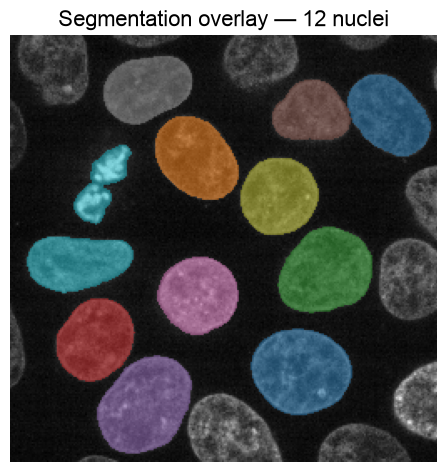

In [3]:
# ── Tunable parameters ────────────────────────────────────────────────────────
SIGMA_UM   = 0.3   # physical smoothing radius in µm (per-axis anisotropic)
H_MIN      = 4     # h_maxima prominence threshold in voxels
MIN_VOXELS = 500   # drop regions below this size (stray fragments only)
MEM_ALPHA  = 0.5   # membrane weight in hybrid watershed surface

# ── 1. Anisotropic Gaussian (both channels) ───────────────────────────────────
sigma_vox = [SIGMA_UM / s for s in SPACING]
smooth_nuc = filters.gaussian(nuclei.astype(float),   sigma=sigma_vox)
smooth_mem = filters.gaussian(membrane.astype(float), sigma=sigma_vox)

# ── 2. Global Otsu + fill holes (nuclei channel) ──────────────────────────────
binary = smooth_nuc > filters.threshold_otsu(smooth_nuc)
binary = ndimage.binary_fill_holes(binary)

# ── 3. h_maxima seeds from nuclei distance transform ──────────────────────────
distance = ndimage.distance_transform_edt(binary)
markers = measure.label(h_maxima(distance, h=H_MIN) & binary)
print(f"Seeds: {markers.max()}")

# ── 4. Hybrid watershed surface ───────────────────────────────────────────────
nuc_n = (smooth_nuc - smooth_nuc.min()) / (smooth_nuc.max() - smooth_nuc.min())
mem_n = (smooth_mem - smooth_mem.min()) / (smooth_mem.max() - smooth_mem.min())
surface = -nuc_n + MEM_ALPHA * mem_n
label_image = watershed(surface, markers, mask=binary)

# ── 5. Per-Z-slice fill holes per nucleus ─────────────────────────────────────
for z in range(label_image.shape[0]):
    for lbl in np.unique(label_image[z]):
        if lbl == 0:
            continue
        sl = label_image[z] == lbl
        filled = ndimage.binary_fill_holes(sl)
        label_image[z][filled & ~sl & (label_image[z] == 0)] = lbl

# ── 6. Remove small fragments and XY-border nuclei ────────────────────────────
for p in measure.regionprops(label_image):
    if p.num_pixels < MIN_VOXELS:
        label_image[label_image == p.label] = 0

xy_border = np.zeros(label_image.shape, dtype=bool)
xy_border[:, 0, :] = True;  xy_border[:, -1, :] = True
xy_border[:, :, 0] = True;  xy_border[:, :, -1] = True
for lbl in set(np.unique(label_image[xy_border])) - {0}:
    label_image[label_image == lbl] = 0

# Renumber contiguously
surviving = np.unique(label_image[label_image > 0])
new_lbl = np.zeros_like(label_image)
for i, lbl in enumerate(surviving, 1):
    new_lbl[label_image == lbl] = i
label_image = new_lbl
n_nuclei = len(surviving)
print(f"Detected {n_nuclei} nuclei (XY-border objects removed)")

# Mid-Z overlay
fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(nuclei[30], cmap='Greys_r')
ax.imshow(np.ma.masked_equal(label_image[30], 0), cmap='tab10', alpha=0.5,
          vmin=1, vmax=n_nuclei)
ax.set_title(f'Segmentation overlay — {n_nuclei} nuclei')
ax.axis('off')
plt.tight_layout()
plt.savefig('../assets/demo_segmented.png', dpi=150, bbox_inches='tight')
plt.show()

## Computing Minkowski Tensors

We call `pk.minkowski_tensors_from_label_image` with `compute="all"` to obtain every Minkowski scalar and tensor for each labelled nucleus. Passing `spacing=SPACING` ensures that marching cubes produces meshes in physical units (µm), so all tensor outputs are in µm-based units.

**Steiner normalization:** pykarambola follows the standard Minkowski-functional convention where the surface-area functional is defined as W₁ = A / 3 (not A itself). Concretely, `w100 = area / 3`. The table below shows both the raw function output and the derived physical quantity so the normalization is explicit.

In [4]:
results = pk.minkowski_tensors_from_label_image(
    label_image, compute="all", spacing=SPACING
)

# spacing is passed to marching_cubes internally, so mesh vertices are already in µm.
# w000 = volume (µm³) — equals V directly, no extra normalization factor
# w100 = area / 3  (Steiner-normalized, units µm²/3); physical area = w100 × 3
# w300 = (2π/3)·χ  (Steiner-normalized); Euler characteristic χ = w300 × 3/(2π)
import numpy as np
print("Minkowski tensor outputs — spacing already applied, units in µm\n")
print(f"{'Nucleus':<10} {'w000 (µm³)':>12} {'Volume (µm³)':>14} "
      f"{'w100 (µm²/3)':>14} {'Area (µm²)':>12} {'β (w020)':>10} {'β (w102)':>10} "
      f"{'w300':>10} {'χ':>6}")
print(f"{'':10} {'[raw output]':>12} {'[= w000]':>14} "
      f"{'[raw, ×1/3]':>14} {'[= w100×3]':>12} {'':>10} {'':>10} "
      f"{'[raw]':>10} {'[=w300×3/2π]':>6}")
print('-' * 106)
for lbl, r in sorted(results.items()):
    volume_phys = r['w000']
    area_norm   = r['w100']
    area_phys   = r['w100'] * 3.0
    w300_raw    = r['w300']
    chi_phys    = w300_raw * 3.0 / (2.0 * np.pi)
    print(f"{lbl:<10} {r['w000']:>12.2f} {volume_phys:>14.2f} "
          f"{area_norm:>14.2f} {area_phys:>12.2f} "
          f"{r['w020_beta']:>10.4f} {r['w102_beta']:>10.4f} "
          f"{w300_raw:>10.4f} {chi_phys:>6.2f}")


Minkowski tensor outputs — spacing already applied, units in µm

Nucleus      w000 (µm³)   Volume (µm³)   w100 (µm²/3)   Area (µm²)   β (w020)   β (w102)       w300      χ
           [raw output]       [= w000]    [raw, ×1/3]   [= w100×3]                            [raw] [=w300×3/2π]
----------------------------------------------------------------------------------------------------------
1                690.59         690.59         150.60       451.81     0.2479     0.4854     4.1888   2.00
2                966.62         966.62         192.05       576.15     0.2433     0.4767     8.3776   4.00
3                770.01         770.01         157.84       473.52     0.2915     0.5169     4.1888   2.00
4                921.66         921.66         186.33       558.99     0.2421     0.5191     4.1888   2.00
5                779.81         779.81         158.98       476.95     0.3684     0.5983     4.1888   2.00
6               1122.14        1122.14         209.54       628.61     0.

## Mesh Visualisation

Each nucleus is reconstructed as a triangulated surface mesh using marching cubes and rendered as a `Poly3DCollection`. Meshes are colour-coded by the anisotropy parameter β (w020_beta), where β → 1 indicates a nearly isotropic (sphere-like) object and lower values indicate elongated or irregular shapes.

The 3D view uses **physical aspect ratio** (`set_box_aspect`) so that Z elongation reflects real µm differences, not axis-scaling artefacts. Axes are ordered X–Y–Z to match the standard microscopy XY-image orientation.

In [ ]:
plt.rcParams['font.family'] = 'Arial'
plt.rcParams.update({
    'font.size':       16,
    'axes.titlesize':  16,
    'axes.labelsize':  15,
    'xtick.labelsize': 13,
    'ytick.labelsize': 13,
})

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

cmap = plt.colormaps['coolwarm']
betas = {lbl: results[lbl]['w020_beta'] for lbl in results}
vmin_b, vmax_b = min(betas.values()), max(betas.values())

# marching_cubes with spacing=(sz, sy, sx) returns verts in (Z, Y, X) order.
# Reorder to (X, Y, Z) to match the standard XY microscopy orientation.
all_xyz = []
for lbl, r in sorted(results.items()):
    mask = (label_image == lbl).astype(np.float32)
    verts, faces, _, _ = measure.marching_cubes(mask, level=0.5, spacing=SPACING)
    verts_xyz = verts[:, [2, 1, 0]]   # ZYX → XYZ
    all_xyz.append(verts_xyz)
    color = cmap((betas[lbl] - vmin_b) / (vmax_b - vmin_b + 1e-9))
    mesh = Poly3DCollection(verts_xyz[faces], alpha=0.6, facecolor=color, edgecolor='none')
    ax.add_collection3d(mesh)

all_xyz_arr = np.vstack(all_xyz)
x_range = all_xyz_arr[:, 0].max() - all_xyz_arr[:, 0].min()
y_range = all_xyz_arr[:, 1].max() - all_xyz_arr[:, 1].min()
z_range = all_xyz_arr[:, 2].max() - all_xyz_arr[:, 2].min()

ax.set_xlim(all_xyz_arr[:, 0].min(), all_xyz_arr[:, 0].max())
ax.set_ylim(all_xyz_arr[:, 1].min(), all_xyz_arr[:, 1].max())
ax.set_zlim(all_xyz_arr[:, 2].min(), all_xyz_arr[:, 2].max())
ax.set_box_aspect([x_range, y_range, z_range])   # physical aspect ratio
ax.zaxis.set_major_locator(plt.MaxNLocator(4))

sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=vmin_b, vmax=vmax_b))
sm.set_array([])
plt.colorbar(sm, ax=ax, label=r'$\beta$ anisotropy ($W_0^{2,0}$)', shrink=0.6)

ax.set_title(r'Nuclei meshes coloured by anisotropy $\beta$ ($W_0^{2,0}$)')
ax.set_xlabel(r'X ($\mu$m)')
ax.set_ylabel(r'Y ($\mu$m)')
ax.set_zlabel(r'Z ($\mu$m)')
ax.view_init(elev=25, azim=-60)   # view close to standard XY orientation
plt.tight_layout()
plt.show()

## PCA + Clustering

Following Schröder-Turk et al. (2013), we build a shape descriptor vector from:

- **4 Minkowski scalars**: `w000` (volume), `w100` (area/3), `w200` (mean curvature), `w300` (Euler characteristic)
- **Per tensor** (`w020`, `w102`, `w120`, `w202`, `w220`, `w320`): β, trace, eigenvalues λ₁λ₂λ₃ (+ trace_ratio where defined)
- **Minkowski structure metrics**: `msm_ql[0..11]`, `msm_wl[0..11]`

We compare four feature subsets of increasing richness to show how descriptor choice affects clustering resolution, then apply the full set to the final analysis.

In [6]:
TENSOR_KEYS = ['w020', 'w102', 'w120', 'w202', 'w220', 'w320']
SCALAR_KEYS = ['w000', 'w100', 'w200', 'w300']

def build_feature_matrix(results, labels, mode='full'):
    """
    Build a feature matrix for the given nucleus labels.

    mode:
      'scalars'   — 4 Minkowski scalars only
      'betas'     — 4 scalars + β for each of the 6 tensor families
      'eigvals'   — 4 scalars + 3 eigenvalues for each tensor family
      'full'      — scalars + β + trace + trace_ratio* + eigvals + msm_ql + msm_wl
    """
    rows, names_out = [], None
    for lbl in labels:
        r = results[lbl]
        feats, names = [], []

        for k in SCALAR_KEYS:
            feats.append(float(r[k])); names.append(k)

        if mode in ('betas', 'eigvals', 'full'):
            for t in TENSOR_KEYS:
                if mode == 'betas':
                    feats.append(float(r[f'{t}_beta'])); names.append(f'{t}_β')
                elif mode == 'eigvals':
                    for i, v in enumerate(r[f'{t}_eigvals']):
                        feats.append(float(v)); names.append(f'{t}_λ{i+1}')
                else:  # full
                    feats.append(float(r[f'{t}_beta']));        names.append(f'{t}_β')
                    feats.append(float(r[f'{t}_trace']));       names.append(f'{t}_trace')
                    if f'{t}_trace_ratio' in r:
                        feats.append(float(r[f'{t}_trace_ratio'])); names.append(f'{t}_tr_ratio')
                    for i, v in enumerate(r[f'{t}_eigvals']):
                        feats.append(float(v)); names.append(f'{t}_λ{i+1}')

        if mode == 'full':
            for i, v in enumerate(r['msm_ql']): feats.append(float(v)); names.append(f'msm_ql[{i}]')
            for i, v in enumerate(r['msm_wl']): feats.append(float(v)); names.append(f'msm_wl[{i}]')

        rows.append(feats)
        if names_out is None:
            names_out = names

    X = np.array(rows)
    valid = ~np.any(np.isnan(X), axis=0)
    return X[:, valid], [n for n, v in zip(names_out, valid) if v]


labels_sorted = sorted(results.keys())
print(f"{len(labels_sorted)} nuclei × feature counts per subset:")
for mode in ('scalars', 'betas', 'eigvals', 'full'):
    X, names = build_feature_matrix(results, labels_sorted, mode)
    print(f"  {mode:<10} {X.shape[1]:>3} features")

12 nuclei × feature counts per subset:
  scalars      4 features
  betas       10 features
  eigvals     22 features
  full        62 features


In [ ]:
plt.rcParams['font.family'] = 'Arial'
plt.rcParams.update({
    'font.size':       16,
    'axes.titlesize':  13,
    'axes.labelsize':  15,
    'xtick.labelsize': 13,
    'ytick.labelsize': 13,
})

# ── Feature-subset comparison ─────────────────────────────────────────────────
# Show how PCA separation changes as we add richer shape descriptors.
# Each subplot uses k=3 Agglomerative Clustering so the comparison is fair.
subsets = [
    ('scalars',  '4 Minkowski scalars'),
    ('betas',    r'4 scalars + $\beta$'),
    ('eigvals',  r'4 scalars + eigenvalues'),
    ('full',     r'Scalars + $\beta$ + eigenvalues + trace + MSM $q_l/w_l$'),
]
colors_cmp = {0: '#2196F3', 1: '#E91E63', 2: '#FF9800'}

# ── PCA plots ─────────────────────────────────────────────────────────────────
subset_clusters = {}   # save cluster assignments for mesh plots below
fig, axes = plt.subplots(2, 2, figsize=(14, 11))
for ax, (mode, title) in zip(axes.flat, subsets):
    X, _ = build_feature_matrix(results, labels_sorted, mode)
    X_sc = StandardScaler().fit_transform(X)
    pca_c = PCA(n_components=2)
    Xp = pca_c.fit_transform(X_sc)
    agg_c = AgglomerativeClustering(n_clusters=3, linkage='complete')
    cl = agg_c.fit_predict(Xp)
    subset_clusters[mode] = cl
    for c in np.unique(cl):
        idx = cl == c
        ax.scatter(Xp[idx, 0], Xp[idx, 1], color=colors_cmp[c],
                   s=90, edgecolors='k', linewidths=0.5)
    for i, lbl in enumerate(labels_sorted):
        ax.annotate(str(lbl), (Xp[i, 0], Xp[i, 1]),
                    fontsize=10, xytext=(3, 3), textcoords='offset points')
    ax.set_title(f'{title}  ({X.shape[1]} features)\n'
                 f'PC1 {pca_c.explained_variance_ratio_[0]*100:.0f}%  '
                 f'PC2 {pca_c.explained_variance_ratio_[1]*100:.0f}%',
                 fontsize=13)
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')

plt.suptitle(r'PCA clustering — feature subset comparison ($k=3$)', fontsize=16)
plt.tight_layout()
plt.show()

# ── Mesh plots for each subset ────────────────────────────────────────────────
# Pre-compute meshes once
meshes = {}
for lbl in labels_sorted:
    mask = (label_image == lbl).astype(np.float32)
    verts, faces, _, _ = measure.marching_cubes(mask, level=0.5, spacing=SPACING)
    meshes[lbl] = (verts[:, [2, 1, 0]], faces)   # ZYX → XYZ

# Compute global axis ranges once so all 4 panels share the same scale
all_verts_global = np.vstack([v for v, _ in meshes.values()])
x_range = all_verts_global[:, 0].max() - all_verts_global[:, 0].min()
y_range = all_verts_global[:, 1].max() - all_verts_global[:, 1].min()
z_range = all_verts_global[:, 2].max() - all_verts_global[:, 2].min()

fig2, axes2 = plt.subplots(2, 2, figsize=(14, 11),
                            subplot_kw={'projection': '3d'})
for ax, (mode, title) in zip(axes2.flat, subsets):
    cl = subset_clusters[mode]
    for lbl in labels_sorted:
        verts_xyz, faces = meshes[lbl]
        c = cl[labels_sorted.index(lbl)]
        ax.add_collection3d(
            Poly3DCollection(verts_xyz[faces], alpha=0.6,
                             facecolor=colors_cmp[c], edgecolor='none'))
        cx, cy, cz = verts_xyz.mean(axis=0)
        ax.text(cx, cy, cz, str(lbl), fontsize=9, fontweight='bold',
                ha='center', va='center', color='white',
                bbox=dict(boxstyle='round,pad=0.1', facecolor='black',
                          alpha=0.4, linewidth=0))
    ax.set_xlim(all_verts_global[:, 0].min(), all_verts_global[:, 0].max())
    ax.set_ylim(all_verts_global[:, 1].min(), all_verts_global[:, 1].max())
    ax.set_zlim(all_verts_global[:, 2].min(), all_verts_global[:, 2].max())
    ax.set_box_aspect([x_range, y_range, z_range])
    ax.zaxis.set_major_locator(plt.MaxNLocator(4))
    ax.set_title(title, fontsize=13)
    ax.set_xlabel(r'X ($\mu$m)', fontsize=13)
    ax.set_ylabel(r'Y ($\mu$m)', fontsize=13)
    ax.set_zlabel(r'Z ($\mu$m)', fontsize=13)
    ax.view_init(elev=25, azim=-60)

plt.suptitle('Meshes coloured by cluster — feature subset comparison', fontsize=16)
plt.tight_layout()
plt.show()

In [ ]:
# ── Assets: full-feature (MSM q_l/w_l) PCA + mesh — saved to assets/ ─────────
X_full, _ = build_feature_matrix(results, labels_sorted, 'full')
X_sc_f    = StandardScaler().fit_transform(X_full)
pca_f     = PCA(n_components=2)
Xp_f      = pca_f.fit_transform(X_sc_f)
cl_f      = AgglomerativeClustering(n_clusters=3, linkage='complete').fit_predict(Xp_f)

# ── PCA scatter ───────────────────────────────────────────────────────────────
fig_pca, ax_pca = plt.subplots(figsize=(7, 6))
for c in np.unique(cl_f):
    idx = cl_f == c
    ax_pca.scatter(Xp_f[idx, 0], Xp_f[idx, 1], color=colors_cmp[c],
                   s=90, edgecolors='k', linewidths=0.5)
for i, lbl in enumerate(labels_sorted):
    ax_pca.annotate(str(lbl), (Xp_f[i, 0], Xp_f[i, 1]),
                    fontsize=10, xytext=(3, 3), textcoords='offset points')
ax_pca.set_xlabel('PC1')
ax_pca.set_ylabel('PC2')
ax_pca.set_title(
    r'Scalars + $\beta$ + eigenvalues + trace + MSM $q_l/w_l$'
    f'  ({X_full.shape[1]} features)\n'
    f'PC1 {pca_f.explained_variance_ratio_[0]*100:.0f}%  '
    f'PC2 {pca_f.explained_variance_ratio_[1]*100:.0f}%',
    fontsize=13,
)
plt.tight_layout()
fig_pca.savefig('../assets/demo_pca_full.png', dpi=150, bbox_inches='tight')
print('Saved → ../assets/demo_pca_full.png')
plt.show()

# ── 3-D mesh coloured by full-feature clusters ────────────────────────────────
# Pre-compute meshes if not already available from the comparison cell above
_meshes_f = {}
for lbl in labels_sorted:
    mask = (label_image == lbl).astype(np.float32)
    verts, faces, _, _ = measure.marching_cubes(mask, level=0.5, spacing=SPACING)
    _meshes_f[lbl] = (verts[:, [2, 1, 0]], faces)   # ZYX → XYZ

_all_v = np.vstack([v for v, _ in _meshes_f.values()])
_xr = _all_v[:, 0].max() - _all_v[:, 0].min()
_yr = _all_v[:, 1].max() - _all_v[:, 1].min()
_zr = _all_v[:, 2].max() - _all_v[:, 2].min()

fig_mesh = plt.figure(figsize=(10, 8))
ax_mesh  = fig_mesh.add_subplot(111, projection='3d')
for lbl in labels_sorted:
    verts_xyz, faces = _meshes_f[lbl]
    c = cl_f[labels_sorted.index(lbl)]
    ax_mesh.add_collection3d(
        Poly3DCollection(verts_xyz[faces], alpha=0.6,
                         facecolor=colors_cmp[c], edgecolor='none'))
    cx, cy, cz = verts_xyz.mean(axis=0)
    ax_mesh.text(cx, cy, cz, str(lbl), fontsize=9, fontweight='bold',
                 ha='center', va='center', color='white',
                 bbox=dict(boxstyle='round,pad=0.1', facecolor='black',
                           alpha=0.4, linewidth=0))

ax_mesh.set_xlim(_all_v[:, 0].min(), _all_v[:, 0].max())
ax_mesh.set_ylim(_all_v[:, 1].min(), _all_v[:, 1].max())
ax_mesh.set_zlim(_all_v[:, 2].min(), _all_v[:, 2].max())
ax_mesh.set_box_aspect([_xr, _yr, _zr])
ax_mesh.zaxis.set_major_locator(plt.MaxNLocator(4))
ax_mesh.set_title(r'Nuclei coloured by cluster (MSM $q_l/w_l$)', fontsize=16)
ax_mesh.set_xlabel(r'X ($\mu$m)')
ax_mesh.set_ylabel(r'Y ($\mu$m)')
ax_mesh.set_zlabel(r'Z ($\mu$m)')
ax_mesh.view_init(elev=25, azim=-60)
plt.tight_layout()
fig_mesh.savefig('../assets/demo_mesh_full.png', dpi=150, bbox_inches='tight')
print('Saved → ../assets/demo_mesh_full.png')
plt.show()

The mitotic cell separation is observable in both the Scalars + eigval and Scalars + β + eigvals + trace + msm_ql/wl feature sets. These feature sets are well-suited for capturing this phenomenon, as they encode complementary geometric and morphological information: scalar quantities describe local volume and curvature, while β, eigenvalues, and trace collectively characterize the spatial distribution of curvature and volume. The msm_ql/wl terms introduce invariants derived from irreducible Minkowski tensors, adding a robust tensorial description of shape. The feature set is restricted to quantities whose geometric meaning is grounded in the intrinsic surface geometry of the cell (Schröder-Turk et al. 2013) rather than its placement within the image. Position-weighted tensors and vector quantities are excluded because their values change with the coordinate frame, which can confound morphological comparisons across cells acquired in different orientations. Furthermore, eigenvalues serve as a particularly powerful descriptor of shape anisotropy, enabling the discrimination of elongated, spherical, or otherwise asymmetric morphologies across a range of tensor types.

## Summary

This notebook demonstrated a complete morphometry pipeline on real 3D fluorescence data:

| Step | Tool | What it captures |
|------|------|------------------|
| Load data | `skimage.data.cells3d` | 60-slice confocal stack, 2 channels |
| Segment nuclei | Gaussian + Otsu + **watershed** | Individually resolved instances, including touching nuclei |
| Minkowski tensors and derived quantities | `pykarambola` | Volume, surface area (Steiner-norm. w100 = A/3), integrated mean curvature, Euler characteristic, β, eigenvalues, trace — shape elongation and surface curvature distribution |
| Anisotropy β | `pykarambola` | β → 1 = sphere-like, β < 1 = elongated/irregular |
| Mesh visualisation | marching cubes + `Poly3DCollection` | Physical-aspect-ratio 3D rendering in XYZ orientation |
| PCA + Agglomerative Clustering | `sklearn` | Unsupervised morphotype discovery |

Minkowski tensors provide a compact description of 3D cell shape that goes far beyond simple volume or surface area — capturing the full anisotropy and curvature distribution of each object via β, eigenvalues, trace, and Minkowski structure metrics (msm_ql, msm_wl), enabling biologically interpretable clustering without hand-crafted features.